In [1]:
# Implementation of a short straddle strategy selling ATM options expiry T = 3 months, no buy backs
# Daily PnL is calculated using capital gains of option premium 

'''
Sell ATM options on days when the portfolio doesn't already have open positions.
Rebalance the portfolio daily based on delta, either buying or short selling the underlying stock.
Calculate daily returns, taking into account the change in option premiums and the profit or loss from rebalancing the underlying stock.
Handle option expiration by checking if the options in the portfolio are expiring on the current day and calculating returns based on whether the options are exercised.
'''

import pandas as pd
import pandas_market_calendars as mcal
import numpy as np
import matplotlib.pyplot as plt
import math as math
from pandas import Timestamp
from equity import find_atm
import equity as eq
import statistics


/Users/emre/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/emre/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/emre/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Load Data
AAPL_options_csv = 'apple_options.csv'
AAPL_underlying_csv = 'apple_stocks.csv'
AAPL_options = pd.read_csv(AAPL_options_csv, parse_dates = ["exdate", "date"])
AAPL_underlying = pd.read_csv(AAPL_underlying_csv, parse_dates = ["date"])
risk_free = pd.read_csv("DGS10.csv", parse_dates = ["DATE"])


In [3]:
def backtest_short_straddle_with_premium_change(options_csv, underlying_csv, options_df, underlying_df, risk_free_df, start_date, number_of_options, expiration_time):
    portfolio = {'options': [], 'underlying': 0, 'premium_costs': 0, "stock_costs": 0}
    daily_returns = []
    nyse_calendar = mcal.get_calendar('NYSE')

    atm_options = find_atm(options_csv, underlying_csv, start_date, number_of_options,expiration_time, 0.1)
    print(atm_options)
    for call_id, put_id in atm_options:
        call_data = options_df.loc[options_df['symbol'] == call_id].iloc[0]
        put_data = options_df.loc[options_df['symbol'] == put_id].iloc[0]
        call_premium = ((call_data['best_bid'] + call_data['best_offer']) / 2) * call_data['contract_size']
        put_premium = ((put_data['best_bid'] + put_data['best_offer']) / 2) * put_data['contract_size']
        portfolio['options'].append({'data': call_data, 'symbol': call_id, 'premium_received': call_premium})
        portfolio['options'].append({'data': put_data, 'symbol': put_id, 'premium_received': put_premium})
        portfolio['premium_costs'] += call_premium + put_premium

    expiry_date_list = []
    for option in portfolio["options"]:
        expiry_date_list.append(option["data"]["exdate"])
    expiry_date_set = set(expiry_date_list)
    max_expiry = max(expiry_date_set)

    trading_days = nyse_calendar.schedule(start_date, max_expiry)
    trading_day_index = mcal.date_range(trading_days, frequency='1D')
    # Change all dates to timestamps, with time 00:00:00
    trading_day_index = [pd.Timestamp(date.date()) for date in trading_day_index]

    for current_date in trading_day_index:
        spot_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        daily_unrealized_pnl = 0  # Initialize daily unrealized profit/loss from options
        # Process options expiring today
        options_to_remove = []
        for option in portfolio['options']:
            option_data_latest = options_df[options_df["date"] == current_date]
            option_data_latest= option_data_latest[option_data_latest["symbol"] == option["symbol"]]
            # Fetch the option data that is most current as of the current_date
            #option_data_latest = options_df.loc[(options_df['symbol'] == option['symbol']) & (options_df['date'] <= current_date)].sort_values(by='date').iloc[-1]
            exdate = option['data']['exdate']

            if exdate == current_date:
                # Calculate and realize P&L from option expiration
                option_type = option["symbol"].split()[1][6]
                pnl = min(spot_price - (option["data"]["strike_price"]/1000), 0) if 'P' == option_type else min(-spot_price + (option["data"]["strike_price"]/1000), 0)
                pnl *= option["data"]['contract_size']
                contract_size = option["data"]['contract_size']
                portfolio['premium_costs'] += pnl
                options_to_remove.append(option)
            else:
                # Calculate unrealized P&L for non-expiring options using the most recent premium information
                current_premium = ((option_data_latest['best_bid'].values[0] + option_data_latest['best_offer'].values[0]) / 2) * option["data"]['contract_size']
                daily_unrealized_pnl -= current_premium 

        print(current_date)
        print("Premium pnl:", daily_unrealized_pnl)
        print("Premium costs:", portfolio["premium_costs"])
        daily_unrealized_pnl += spot_price * portfolio["underlying"]
        print("Number of stocks:", portfolio["underlying"])
        print("Stock pnl:", spot_price * portfolio["underlying"])
        print("Stock costs:", portfolio["stock_costs"])
        print("Total pnl:", daily_unrealized_pnl)
        print("Total costs:", portfolio['premium_costs'] + portfolio["stock_costs"])
        print("Total real pnl:", daily_unrealized_pnl + portfolio['premium_costs'] + portfolio["stock_costs"])
        print("Spot price:", spot_price)
        # Remove expired options
        for option in options_to_remove:
            portfolio['options'].remove(option)

        # Daily rebalance based on delta
        portfolio_option_symbols = [option['symbol'] for option in portfolio['options']]
        daily_pnl = daily_unrealized_pnl + portfolio["premium_costs"] + portfolio["stock_costs"] # Update to include cash change

        print("Number of stocks before hedge:", portfolio["underlying"])
        
        contract_size = 100 # TODO: Fix this
        delta_without_stocks = eq.get_total_delta(options_df, underlying_df, risk_free_df, portfolio_option_symbols, current_date)
        delta_with_stocks = delta_without_stocks - (portfolio["underlying"] * (1/contract_size))
        print("Delta before hedge:", delta_with_stocks)
        #print(current_date)
        #print("Delta before hedging", delta_with_stocks)
        if current_date != trading_day_index:
            if (abs(delta_with_stocks) > 0.1):
                hedge_count = -int(round(delta_with_stocks * contract_size))
                portfolio["stock_costs"] += hedge_count * spot_price
                portfolio["underlying"] -= hedge_count

        delta_without_stocks = eq.get_total_delta(options_df, underlying_df, risk_free_df, portfolio_option_symbols, current_date)
        delta_with_stocks = delta_without_stocks - (portfolio["underlying"] * (1/contract_size))

        print("Delta after hedge:", delta_with_stocks)
        print("Number of stocks after hedge:", portfolio["underlying"])

        
        #print("Delta after hedging", delta_with_stocks)
        # Add daily unrealized P&L from options to daily returns
        # Calculate and include real cash changes in daily P&L

        
    
        daily_returns.append(daily_pnl)

    return pd.Series(daily_returns, index=trading_day_index)

In [ ]:
# Execute the backtest
daily_returns = backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, AAPL_options['date'].min())

In [ ]:
# Assuming daily_returns is a pandas Series with a datetime index
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns.index, daily_returns.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

i = 0
with open("daily_returns.txt", "w") as file:
    for value in daily_returns:
        file.write(str(value) + " " + str(daily_returns.index[i]) + "\n")
        i += 1

print("std:", statistics.stdev(daily_returns))

        

In [4]:
# Load Data
VRZ_options_csv = 'verizon_options.csv'
VRZ_underlying_csv = 'verizon_stocks.csv'
VRZ_options = pd.read_csv(VRZ_options_csv, parse_dates = ["exdate", "date"])
VRZ_underlying = pd.read_csv(VRZ_underlying_csv, parse_dates = ["date"])
daily_returns = backtest_short_straddle_with_premium_change(VRZ_options_csv, VRZ_underlying_csv,VRZ_options, VRZ_underlying, risk_free, VRZ_options['date'].min())

[('VZ 190621C60000', 'VZ 190621P60000'), ('VZ 190621C52500', 'VZ 190621P52500'), ('VZ 190621C55000', 'VZ 190621P55000'), ('VZ 190621C57500', 'VZ 190621P57500')]
2019-01-02 00:00:00
Premium pnl: -2883.5
Premium costs: 2883.5
Number of stocks: 0
Stock pnl: 0.0
Stock costs: 0
Total pnl: -2883.5
Total costs: 2883.5
Total real pnl: 0.0
Spot price: 56.02
Number of stocks before hedge: 0
Delta before hedge: 0.4304498704141803
Delta after hedge: 0.00044987041418032003
Number of stocks after hedge: 43
2019-01-03 00:00:00
Premium pnl: -2955.0
Premium costs: 2883.5
Number of stocks: 43
Stock pnl: 2417.46
Stock costs: -2408.86
Total pnl: -537.54
Total costs: 474.6399999999999
Total real pnl: -62.90000000000009
Spot price: 56.22
Number of stocks before hedge: 43
Delta before hedge: 0.05932555590268196
Delta after hedge: 0.05932555590268196
Number of stocks after hedge: 43
2019-01-04 00:00:00
Premium pnl: -2755.5
Premium costs: 2883.5
Number of stocks: 43
Stock pnl: 2423.48
Stock costs: -2408.86
Tot

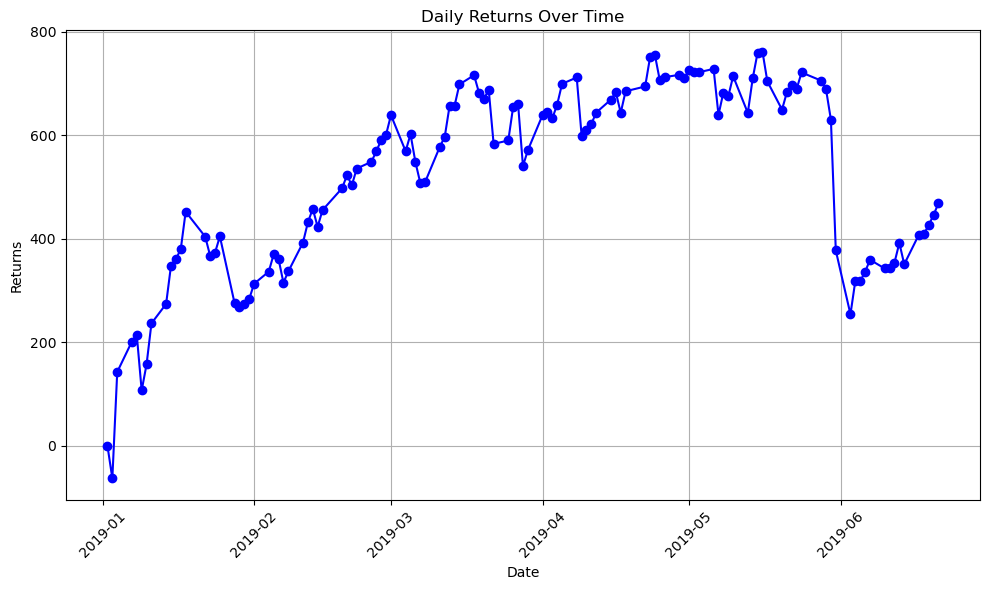

182.933713274547


In [5]:
# Assuming daily_returns is a pandas Series with a datetime index
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns.index, daily_returns.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

i = 0
with open("daily_returns.txt", "w") as file:
    for value in daily_returns:
        file.write(str(value) + " " + str(daily_returns.index[i]) + "\n")
        i += 1

        
print(statistics.stdev(daily_returns))

In [ ]:
def backtest_short_straddle_with_premium_change(options_csv, underlying_csv, options_df, underlying_df, risk_free_df, start_date):
    portfolio = {'options': [], 'cash': 0}
    daily_returns = []
    nyse_calendar = mcal.get_calendar('NYSE')

    atm_options = find_atm(options_csv, underlying_csv, start_date, 5, 180, 0.1)
    print(atm_options)
    for call_id, put_id in atm_options:
        call_data = options_df.loc[options_df['symbol'] == call_id].iloc[0]
        put_data = options_df.loc[options_df['symbol'] == put_id].iloc[0]
        call_premium = ((call_data['best_bid'] + call_data['best_offer']) / 2) * call_data['contract_size']
        put_premium = ((put_data['best_bid'] + put_data['best_offer']) / 2) * put_data['contract_size']
        portfolio['options'].append({'data': call_data, 'symbol': call_id, 'premium_received': call_premium})
        portfolio['options'].append({'data': put_data, 'symbol': put_id, 'premium_received': put_premium})
        portfolio['cash'] += call_premium + put_premium

    expiry_date_list = []
    for option in portfolio["options"]:
        expiry_date_list.append(option["data"]["exdate"])
    expiry_date_set = set(expiry_date_list)
    max_expiry = max(expiry_date_set)

    trading_days = nyse_calendar.schedule(start_date, max_expiry)
    trading_day_index = mcal.date_range(trading_days, frequency='1D')
    # Change all dates to timestamps, with time 00:00:00
    trading_day_index = [pd.Timestamp(date.date()) for date in trading_day_index]

    for current_date in trading_day_index:
        spot_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        daily_unrealized_pnl = 0  # Initialize daily unrealized profit/loss from options
        # Process options expiring today
        options_to_remove = []
        for option in portfolio['options']:
            option_data_latest = options_df[options_df["date"] == current_date]
            option_data_latest= option_data_latest[option_data_latest["symbol"] == option["symbol"]]
            # Fetch the option data that is most current as of the current_date
            #option_data_latest = options_df.loc[(options_df['symbol'] == option['symbol']) & (options_df['date'] <= current_date)].sort_values(by='date').iloc[-1]
            exdate = option['data']['exdate']

            if exdate == current_date:
                # Calculate and realize P&L from option expiration
                option_type = option["symbol"].split()[1][6]
                pnl = min(spot_price - (option["data"]["strike_price"]/1000), 0) if 'P' == option_type else min(-spot_price + (option["data"]["strike_price"]/1000), 0)
                pnl *= option["data"]['contract_size']
                portfolio['cash'] += pnl
                options_to_remove.append(option)
            else:
                # Calculate unrealized P&L for non-expiring options using the most recent premium information
                current_premium = ((option_data_latest['best_bid'].values[0] + option_data_latest['best_offer'].values[0]) / 2) * option["data"]['contract_size']
                daily_unrealized_pnl -= current_premium 

        # Remove expired options
        for option in options_to_remove:
            portfolio['options'].remove(option)

        daily_pnl = daily_unrealized_pnl + portfolio["cash"] # Update to include cash change

        # Add daily unrealized P&L from options to daily returns
        # Calculate and include real cash changes in daily P&L
    
        daily_returns.append(daily_pnl)

    return pd.Series(daily_returns, index=trading_day_index)

In [ ]:
daily_returns_no_hedge = backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, AAPL_options['date'].min())

In [ ]:
# Assuming daily_returns is a pandas Series with a datetime index
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns_no_hedge.index, daily_returns_no_hedge.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

i = 0
with open("daily_returns_no_hedge.txt", "w") as file:
    for value in daily_returns_no_hedge:
        file.write(str(value) + " " + str(daily_returns_no_hedge.index[i]) + "\n")
        i += 1

print("std:", statistics.stdev(daily_returns_no_hedge))

        